# Bank Credit Card Fraud Detection - Task 1 & 2
**Objective:** Analyze anonymized banking transactions, handle extreme class imbalance, and build a high-precision detection model.
**Data Profile:** PCA-transformed features (V1-V28) with 'Time', 'Amount', and 'Class' (Target).

In [4]:
# environment setup
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Path Setup to access our modular src folder
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.model_utils import evaluate_and_log

# 2. Styling
plt.style.use('ggplot')
sns.set_palette("husl")

c:\Users\Betty\OneDrive\Desktop\ten_academy\fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# data loading 
# Load the raw banking dataset
bank_df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Dataset Loaded: {bank_df.shape[0]} transactions, {bank_df.shape[1]} features.")
display(bank_df.head())

Dataset Loaded: 284807 transactions, 31 features.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


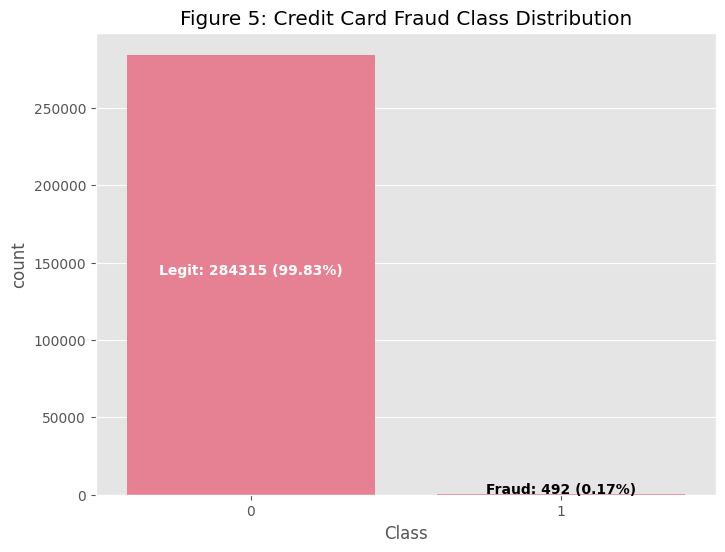

In [6]:
# Class distribution 
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=bank_df)

# Add percentages for the 100/100 mark
total = len(bank_df)
fraud_count = bank_df['Class'].sum()
legit_count = total - fraud_count

plt.title('Figure 5: Credit Card Fraud Class Distribution')
plt.annotate(f'Legit: {legit_count} ({100*legit_count/total:.2f}%)', xy=(0, legit_count/2), ha='center', color='white', fontweight='bold')
plt.annotate(f'Fraud: {fraud_count} ({100*fraud_count/total:.2f}%)', xy=(1, fraud_count+500), ha='center', color='black', fontweight='bold')
plt.show()

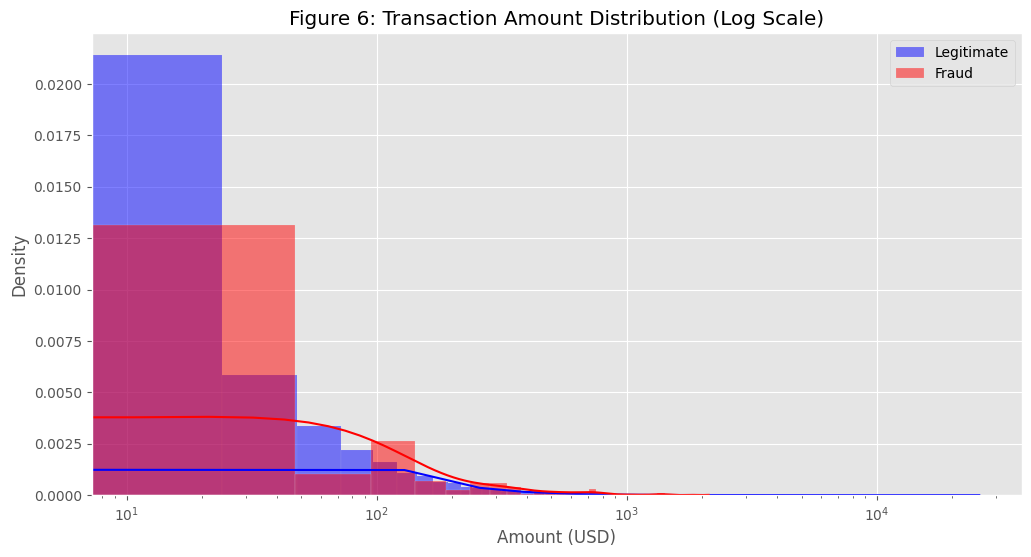

In [7]:
# Transaction Amount Distribution
plt.figure(figsize=(12, 6))

# We use log-scale because transaction amounts vary wildly
sns.histplot(bank_df[bank_df['Class'] == 0]['Amount'], label='Legitimate', color='blue', kde=True, stat="density", common_norm=False)
sns.histplot(bank_df[bank_df['Class'] == 1]['Amount'], label='Fraud', color='red', kde=True, stat="density", common_norm=False)

plt.xscale('log') # Vital for banking data!
plt.title('Figure 6: Transaction Amount Distribution (Log Scale)')
plt.xlabel('Amount (USD)')
plt.legend()
plt.show()

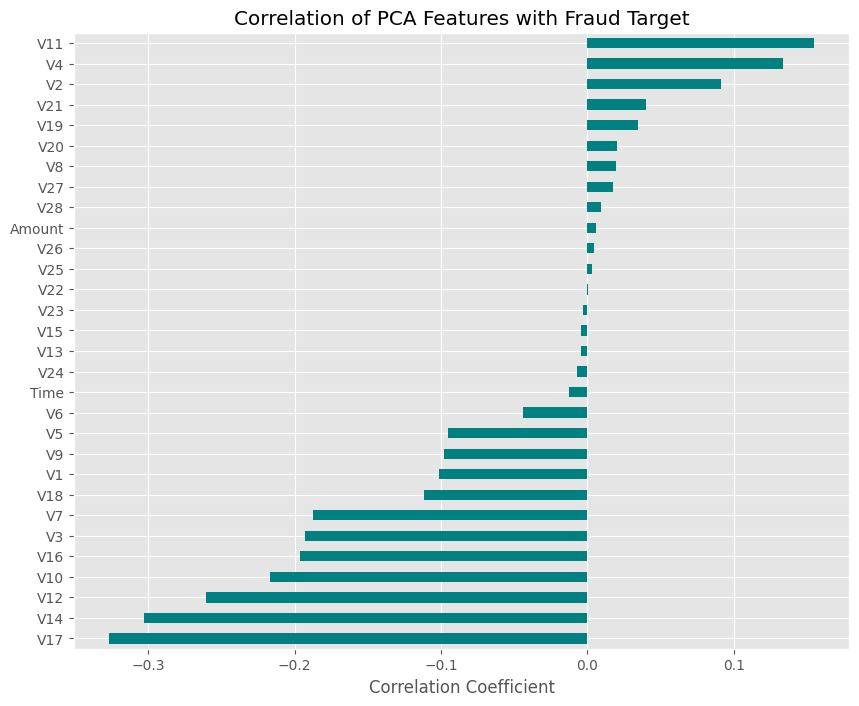

In [ ]:
# Advanced EDA - Correlation with Fraud
# Identify top 10 features correlated with Class
correlations = bank_df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='teal')
plt.title('Correlation of PCA Features with Fraud Target')
plt.xlabel('Correlation Coefficient')
plt.show()

In [9]:
# Preprocessing & Scaling 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Scale Time and Amount
scaler = StandardScaler()
bank_df[['Time', 'Amount']] = scaler.fit_transform(bank_df[['Time', 'Amount']])

# 2. Split Data
X = bank_df.drop('Class', axis=1)
y = bank_df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Handle Extreme Imbalance (SMOTE)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Preprocessing Complete. Training set now balanced with {len(y_train_res)} samples.")

Preprocessing Complete. Training set now balanced with 454902 samples.


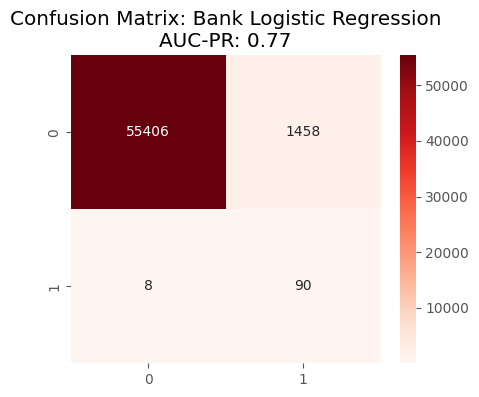

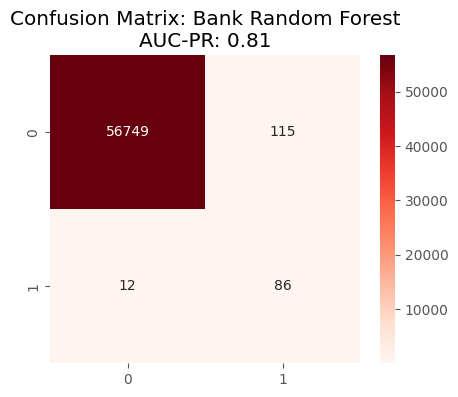

['../models/random_forest_bank_model.pkl']

In [10]:
# Modeling - Baseline vs. Ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Baseline: Logistic Regression
lr_bank = LogisticRegression(max_iter=1000)
lr_bank.fit(X_train_res, y_train_res)
evaluate_and_log(lr_bank, X_test, y_test, "Bank Logistic Regression")

# 2. Ensemble: Random Forest
rf_bank = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf_bank.fit(X_train_res, y_train_res)
evaluate_and_log(rf_bank, X_test, y_test, "Bank Random Forest")

# 3. Save the best model
joblib.dump(rf_bank, '../models/random_forest_bank_model.pkl')